# 1. Configuración del Entorno y Carga de Datos

En esta sección inicial preparamos el entorno de trabajo importando las librerías fundamentales para el análisis numérico, manipulación de datos y visualización estadística. Asimismo, establecemos los parámetros estéticos globales para garantizar un estándar visual profesional y homogéneo en todos los gráficos del proyecto.

### Objetivos:
*   Importar las dependencias esenciales del ecosistema de Data Science.
*   Configurar estilos visuales consistentes (grillas, paletas de colores y dimensiones por defecto).
*   Cargar el dataset de simulación energética e inspeccionar su estructura general (volumen de datos y tipos de variables).

---

### Glosario Técnico de esta Sección

#### Librerías Importadas:
*   `pandas (pd)`: Librería fundamental para la manipulación y análisis de datos estructurados mediante su estructura principal, el *DataFrame*.
*   `numpy (np)`: Soporte para vectores y matrices multidimensionales, junto con una colección de funciones matemáticas de alto nivel.
*   `matplotlib.pyplot (plt)`: Interfaz basada en estados que provee una forma de graficar similar a MATLAB, encargada de la infraestructura base de los gráficos.
*   `seaborn (sns)`: Librería de visualización de datos estadísticos basada en Matplotlib que ofrece una interfaz de alto nivel para crear gráficos atractivos e informativos.

#### Funciones Utilizadas:
*   `sns.set_theme()`: Configura el diseño global de los gráficos. Usamos `style="whitegrid"` para añadir una cuadrícula de fondo que facilita la lectura de valores, y `palette="muted"` para aplicar una paleta de colores sobria y profesional.
*   `plt.rcParams['figure.figsize']`: Modifica el diccionario de parámetros en tiempo de ejecución de Matplotlib para fijar el tamaño por defecto de todas las figuras a 10 pulgadas de ancho por 6 de alto.
*   `pd.read_csv()`: Función analítica que lee un archivo de valores separados por comas (CSV) y lo transforma en un objeto DataFrame en memoria.
*   `print()`: Función nativa de Python utilizada para dar formato y salida de texto explícita en la consola de resultados.
*   `df.info()`: Método de Pandas que realiza un diagnóstico de la estructura del DataFrame, mostrando el índice, los tipos de datos de cada columna (`dtypes`), la cantidad de valores no nulos y el uso estimado de la memoria RAM.

#### Variables y Atributos Creados:
*   `df`: Variable que almacena el *DataFrame* generado. Es la estructura de datos central sobre la cual ejecutaremos todo el EDA.
*   `df.shape`: Atributo bidimensional del DataFrame que devuelve una tupla con la cantidad de filas y columnas, permitiendo conocer el volumen bruto de la matriz de datos (`shape[0]` para filas, `shape[1]` para columnas).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carga de datos
url = "https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/feature/generacion-datos/data/dataset_consumo_energetico_inventado_17%E2%81%8407%E2%81%8426.csv"
df = pd.read_csv(url)

# Inspección inicial
print(f"Dimensiones del dataset: {df.shape}")
df.info()

Dimensiones del dataset: (10100, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10100 non-null  int64  
 1   tipo_vivienda                 10100 non-null  object 
 2   metros_cuadrados              10100 non-null  float64
 3   habitaciones                  10100 non-null  int64  
 4   baños                         10100 non-null  int64  
 5   antiguedad_vivienda           9639 non-null   float64
 6   aislamiento                   10100 non-null  object 
 7   eficiencia_construccion       10100 non-null  object 
 8   paneles_solares               10100 non-null  bool   
 9   cantidad_personas             10100 non-null  int64  
 10  trabajo_remoto                10100 non-null  bool   
 11  horas_en_casa                 9811 non-null   float64
 12  ingreso_mensual        

# 2. Limpieza de Datos y Consistencia Estructural (Data Cleaning)

En esta fase garantizamos la calidad y la integridad de los datos antes de proceder con el análisis estadístico. El objetivo es eliminar redundancias que alteren las distribuciones (duplicados) y resolver la ausencia de información (valores faltantes) mediante estrategias de imputación robustas.

### Criterio Estadístico:
Para las variables numéricas que presentan valores nulos (`ingreso_mensual`, `antiguedad_vivienda`, etc.), optamos por una **imputación basada en la mediana** en lugar de la media aritmética. Al tratarse de un dataset de simulación donde se inyectaron comportamientos específicos y posibles valores atípicos (*outliers*), la mediana actúa como un estimador central robusto que no se ve sesgado por valores extremos, preservando mejor la representatividad de la muestra.

### Objetivos:
*   Identificar y remover registros duplicados basados en sus características de consumo (ignorando identificadores únicos arbitrarios como el `id`).
*   Cuantificar el impacto y la distribución de los valores faltantes (*missing values*) por columna.
*   Aplicar una estrategia de imputación matemática para normalizar las variables numéricas incompletas.

---

### Glosario Técnico de esta Sección

#### Funciones y Métodos Utilizados:
*   `df.duplicated()`: Método de Pandas que evalúa fila por fila y devuelve una serie booleana (`True` si el registro ya apareció antes, `False` si es único).
*   `df.columns.difference()`: Función de conjuntos que devuelve un índice con los nombres de las columnas, excluyendo explícitamente los campos indicados en la lista (en este caso, remueve `'id'`).
*   `.sum()`: Operación de agregación matemática. Aplicada sobre series booleanas, convierte los valores `True` en 1 y `False` en 0, permitiendo totalizar los registros encontrados.
*   `df.drop_duplicates()`: Elimina las filas redundantes del DataFrame basándose en el subconjunto de columnas analizado.
*   `df.isnull()`: Genera una máscara booleana del mismo tamaño que el DataFrame, donde cada celda se marca como `True` si contiene un valor nulo (`NaN` o `None`).
*   `df[col].median()`: Calcula el percentil 50 de una distribución numérica, identificando el valor central de la serie ordenada.
*   `df[col].fillna()`: Reemplaza todos los valores faltantes (`NaN`) de una columna específica con el valor escalar que se le pase como argumento.

#### Parámetros Técnicos Clave:
*   `subset`: Argumento de control que delimita qué columnas debe inspeccionar el algoritmo para determinar si un registro es idéntico a otro.
*   `keep='first'`: Parámetro crítico de depuración que le indica a Pandas que conserve intacta la primera ocurrencia del registro duplicado y proceda a borrar las repeticiones posteriores.

#### Variables Creadas:
*   `duplicados`: Variable escalar de tipo entero (`int`) que almacena la cantidad total de filas redundantes detectadas en la matriz.
*   `nulos_por_columna`: Serie de Pandas cuyo índice son los nombres de las columnas y sus valores indican la cantidad absoluta de registros faltantes.
*   `cols_num_nulas`: Lista nativa de Python (`list`) que indexa las variables numéricas identificadas como incompletas para iterar sobre ellas de forma automatizada.
*   `col`: Variable de control del ciclo `for` que almacena temporalmente el nombre de la columna que se está procesando en la iteración actual.

In [4]:
# 1.1 Detección y eliminación de duplicados
duplicados = df.duplicated(subset=df.columns.difference(['id'])).sum()
print(f"Duplicados encontrados (ignorando ID): {duplicados}")

# Eliminamos conservando la primera aparición
df = df.drop_duplicates(subset=df.columns.difference(['id']), keep='first')

# 1.2 Análisis de Valores Faltantes (Missing Values)
nulos_por_columna = df.isnull().sum()
print("\nValores nulos por columna:")
print(nulos_por_columna[nulos_por_columna > 0])

# Estrategia de Imputación básica (puedes sofisticarla después)
# Para numéricas: Usamos la mediana por ser robusta a los outliers que inyectamos
cols_num_nulas = ['ingreso_mensual', 'antiguedad_vivienda', 'electrodomesticos_eficientes', 'horas_en_casa']
for col in cols_num_nulas:
    df[col] = df[col].fillna(df[col].median())

Duplicados encontrados (ignorando ID): 100

Valores nulos por columna:
antiguedad_vivienda             454
horas_en_casa                   287
ingreso_mensual                 435
electrodomesticos_eficientes    273
dtype: int64


# 3. Análisis Univariado: Distribución del Target y Consumo

En esta sección iniciamos la exploración visual del dataset enfocándonos en dos frentes críticos: evaluar el balance de nuestra variable objetivo (*target*) e inspeccionar la morfología y presencia de valores atípicos (*outliers*) en la variable numérica principal de consumo.

### Importancia del Análisis:
*   **Variable Objetivo (`categoria`):** Comprender el balance de clases es vital. Si los datos simulados muestran un desbalance severo (por ejemplo, muchísimas viviendas ineficientes y casi ninguna eficiente), los futuros modelos de Machine Learning desarrollarán un sesgo predictivo hacia la clase mayoritaria.
*   **Variable Continua (`consumo_kwh`):** El uso combinado de un histograma con estimación de densidad kernel (KDE) y un diagrama de caja (*boxplot*) nos permite diagnosticar si el consumo sigue una distribución normal o si presenta una cola larga (comportamiento asimétrico/log-normal). El *boxplot* delimita geométricamente los límites estadísticos para clasificar formalmente qué registros constituyen *outliers* extremos inyectados en la simulación.

### Objetivos:
*   Graficar la frecuencia absoluta de las tres categorías de eficiencia energética del dataset.
*   Visualizar la asimetría y el comportamiento de la densidad del consumo eléctrico en kilovatios-hora (kWh).
*   Identificar visualmente la presencia de valores atípicos mediante el método de rango intercuartílico reflejado en el gráfico de caja.

---

###  Glosario Técnico de esta Sección

#### Funciones y Métodos de Visualización:
*   `plt.figure()`: Inicializa una nueva figura independiente en Matplotlib configurando sus dimensiones específicas en pulgadas mediante el parámetro `figsize`.
*   `sns.countplot()`: Gráfico estadístico de Seaborn que cuenta la frecuencia de ocurrencia de una variable categórica y la representa mediante barras verticales u horizontales.
*   `plt.subplots()`: Función de conveniencia que crea una grilla contenedora para múltiples gráficos dentro de una misma ventana visual. Devuelve la figura base y una matriz de ejes (`axes`) sobre los cuales dibujar de forma independiente.
*   `sns.histplot()`: Grafica un histograma para aproximar la distribución de probabilidad de una variable continua, dividiendo los datos en contenedores (*bins*).
*   `sns.boxplot()`: Diagrama de caja y bigotes que resume una distribución numérica mostrando sus cuartiles ($Q_1$, $Q_2$/Mediana, $Q_3$) y marcando como puntos aislados los valores que superan los límites del rango intercuartílico (IQR).
*   `plt.show()`: Limpia el buffer interno de Matplotlib y renderiza de manera definitiva las figuras en la interfaz del notebook, eliminando salidas de texto de bajo nivel molestas.

#### Parámetros Técnicos Clave:
*   `order`: Lista explícita nativa de Python que le instruye a Seaborn el orden secuencial de izquierda a derecha en el que debe ordenar las categorías en el eje X.
*   `bins=50`: Define la cantidad exacta de intervalos o barras verticales en los que se dividirá el rango total de la variable continua en el histograma.
*   `kde=True`: (*Kernel Density Estimation*) Superpone una línea suavizada que representa la estimación matemática de la función de densidad de probabilidad continua de los datos.
*   `ax=axes[0]` / `ax=axes[1]`: Argumento de enrutamiento que le indica a la función de Seaborn exactamente en qué celda o coordenada de la grilla de subplots debe renderizar el gráfico.

#### Variables y Componentes Creados:
*   `fig`: Objeto contenedor de Matplotlib que administra la ventana global de los subplots.
*   `axes`: Arreglo de NumPy que contiene las referencias de cada panel de dibujo independiente (`axes[0]` para el panel izquierdo, `axes[1]` para el derecho).

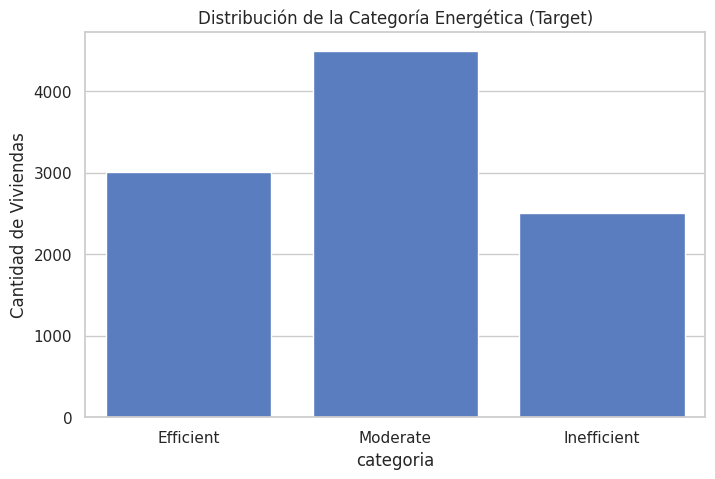

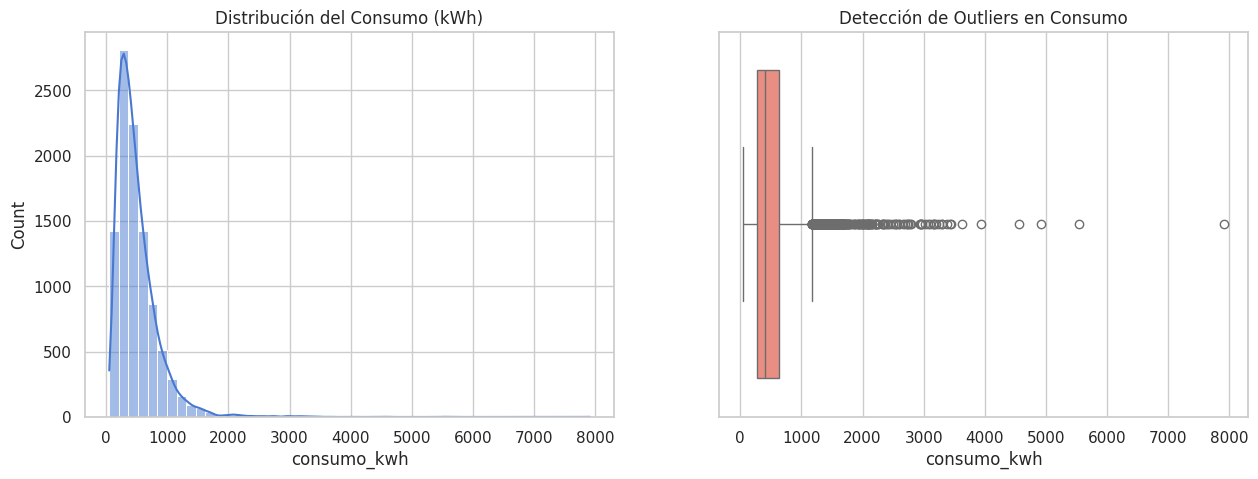

In [5]:
# 2.1 Distribución de la Variable Objetivo (Desbalanceo)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='categoria', order=['Efficient', 'Moderate', 'Inefficient'])
plt.title('Distribución de la Categoría Energética (Target)')
plt.ylabel('Cantidad de Viviendas')
plt.show()

# 2.2 Distribución del Consumo y Detección de Outliers Extremos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma para ver la cola larga (Log-normalidad)
sns.histplot(df['consumo_kwh'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribución del Consumo (kWh)')

# Boxplot para visualizar los outliers extremos
sns.boxplot(x=df['consumo_kwh'], ax=axes[1], color='salmon')
axes[1].set_title('Detección de Outliers en Consumo')
plt.show()

###  Conclusiones del Análisis Univariado:

1. **Balance de la Variable Objetivo (`categoria`):** La muestra presenta una distribución relativamente equilibrada, liderada por la categoría `Moderate` (aprox. 4,500 viviendas), seguida de `Efficient` (3,000) e `Inefficient` (2,500). Al no existir un desbalance extremo de clases, el dataset es apto para el entrenamiento posterior de modelos de clasificación sin requerir técnicas severas de remuestreo (como SMOTE).
2. **Morfología del Consumo (`consumo_kwh`):** El histograma revela una distribución marcadamente asimétrica positiva (cola larga hacia la derecha), característica típica de datos log-normales de consumo en el mundo real. La mayor densidad de viviendas se concentra en consumos menores a los 1,000 kWh.
3. **Presencia de Anomalías (Outliers):** El diagrama de caja (*boxplot*) confirma geométricamente la existencia de una alta densidad de valores atípicos a partir del umbral de los 1,200 kWh. Destacan casos ultra extremos con consumos que escalan entre 4,000 kWh y 8,000 kWh, los cuales representan objetivos críticos de auditoría para nuestro sistema de eficiencia.

# 4. Análisis Bivariado: Factores que Conducen al Consumo Energético

En esta sección avanzamos hacia el análisis bivariado para evaluar de qué manera las características estructurales de los inmuebles (superficie en metros cuadrados, tipo de propiedad y calidad del aislamiento térmico) condicionan o mitigan el consumo eléctrico global.

### Fundamentos del Análisis:
*   **Consumo vs. Superficie (`scatterplot`):** Nos permite evaluar visualmente la hipótesis de correlación lineal (a mayor tamaño del inmueble, mayor demanda energética). Al incorporar la variable categórica `tipo_vivienda` como dimensión cromática (`hue`), podemos identificar si la tasa de crecimiento del consumo se comporta de manera homogénea entre departamentos, casas o complejos industriales.
*   **Consumo vs. Aislamiento (`boxplot` adaptado):** El aislamiento térmico es una barrera física crítica para la eficiencia. Aquí contrastamos las distribuciones de consumo para cada nivel de calidad.
*   **Truncado Estadístico mediante Cuantiles:** Dado que en la sección anterior detectamos *outliers* extremos (viviendas rozando los 8000 kWh), si dejáramos el eje Y libre, las cajas se verían aplastadas en la base del gráfico. Aplicamos un límite superior dinámico fijado en el **percentil 95** (`quantile(0.95)`). Esto remueve temporalmente el 5% de los datos más exagerados de la vista, permitiéndonos apreciar con máxima claridad y nitidez la diferencia real entre las cajas centrales.

### Objetivos:
*   Identificar patrones de dispersión y correlación entre la dimensión física del inmueble y su gasto energético.
*   Comparar visualmente el impacto de los cuatro niveles de aislamiento térmico sobre las medianas de consumo.
*   Optimizar la escala de visualización mediante técnicas avanzadas de filtrado por cuantiles para mitigar el efecto de dispersión de los *outliers*.

---

### Glosario Técnico de esta Sección

#### Funciones y Métodos Utilizados:
*   `sns.scatterplot()`: Gráfico de dispersión matemática que dibuja puntos en coordenadas cartesianas bidimensionales ($X, Y$) para evaluar la relación o dependencia entre dos variables continuas.
*   `df['consumo_kwh'].quantile(0.95)`: Función estadística de Pandas que calcula el valor por debajo del cual se encuentra el 95% de todas las observaciones de la columna de consumo, sirviendo como umbral de corte robusto.
*   `plt.ylim()`: Delimita explícitamente los límites numéricos inferior y superior del eje vertical (Y) en la figura activa de Matplotlib.

#### Parámetros Técnicos Clave:
*   `hue`: Dimensión de mapeo semántico o cromático. Recibe el nombre de una columna categórica y segmenta los datos asignándoles colores diferenciados a cada grupo dentro del mismo gráfico.
*   `alpha=0.6`: Controla la transparencia de los elementos gráficos (puntos del scatterplot). Un valor de 0.6 (60% de opacidad) ayuda a mitigar el problema del *overplotting* (puntos encimados), revelando dónde hay mayor densidad de datos mediante la intensificación del color.
*   `order`: Define el ordenamiento jerárquico cualitativo para las categorías del eje X en el boxplot (de 'Poor' a 'Excellent').

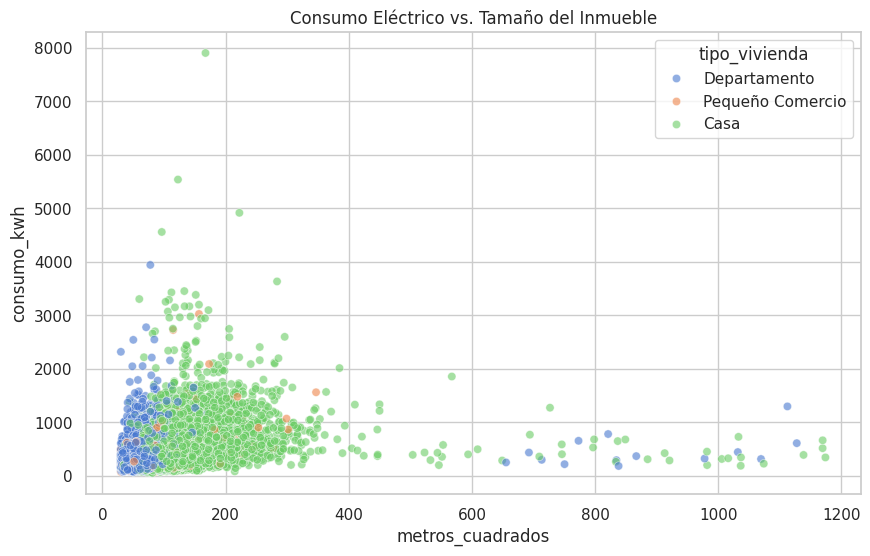

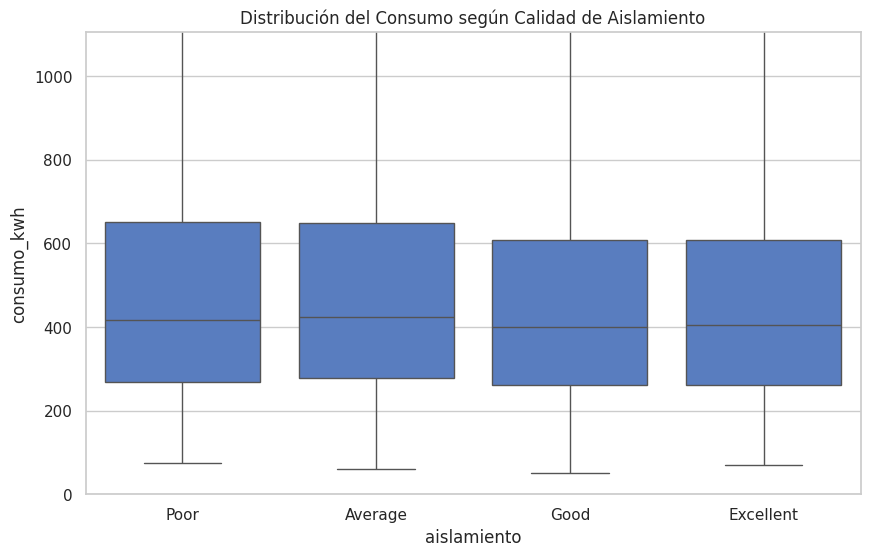

In [6]:
# 3.1 Relación entre Metros Cuadrados, Consumo y Tipo de Vivienda
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='metros_cuadrados', y='consumo_kwh', hue='tipo_vivienda', alpha=0.6)
plt.title('Consumo Eléctrico vs. Tamaño del Inmueble')
plt.show()

# 3.2 Impacto del Aislamiento Térmico en el Consumo
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='aislamiento', y='consumo_kwh',
            order=['Poor', 'Average', 'Good', 'Excellent'])
plt.title('Distribución del Consumo según Calidad de Aislamiento')
# Limitamos el eje Y para que los outliers extremos no aplasten el gráfico
plt.ylim(0, df['consumo_kwh'].quantile(0.95))
plt.show()

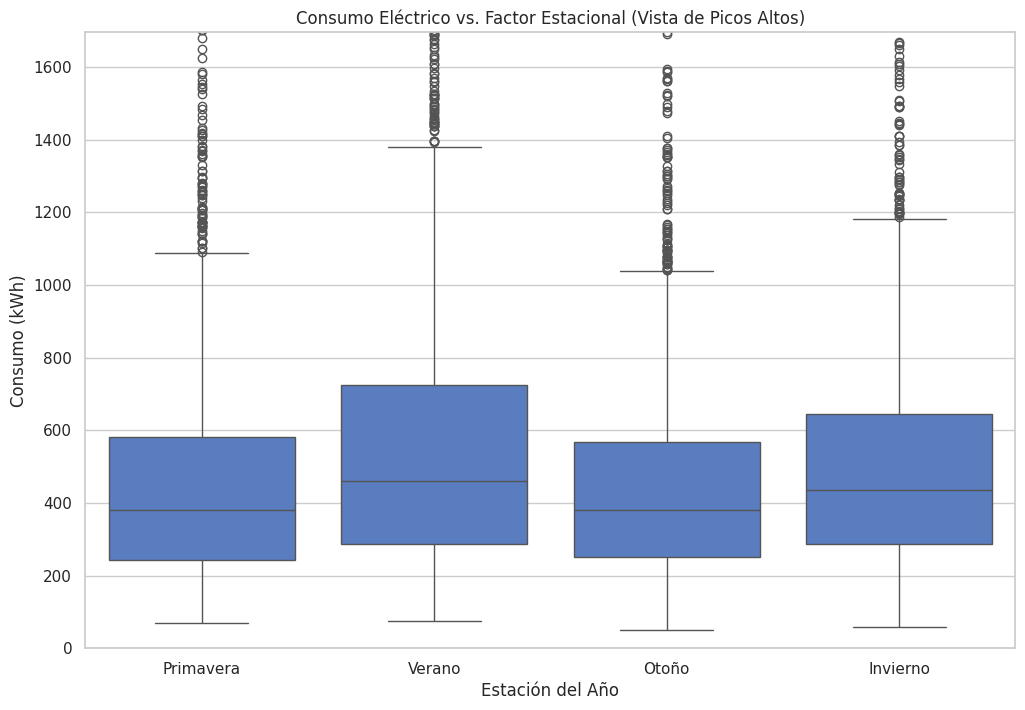

In [14]:
# 3.3 Relación entre Consumo Eléctrico y Factor Estacional
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='factor_estacional', y='consumo_kwh',
            order=['Primavera', 'Verano', 'Otoño', 'Invierno'])

plt.title('Consumo Eléctrico vs. Factor Estacional (Vista de Picos Altos)')
plt.xlabel('Estación del Año')
plt.ylabel('Consumo (kWh)')

# Ajustamos el límite al percentil 99 para capturar casi todos los picos altos
# pero evitando que el outlier de 8000 aplaste la visualización central.
plt.ylim(0, df['consumo_kwh'].quantile(0.99))
plt.show()

###  Conclusiones del Análisis Bivariado:
1. Se observa una clara segmentación estructural: los departamentos se restringen a superficies menores a 100m², mientras que las casas representan la mayor variabilidad de tamaño y los picos más altos de consumo.
2. Existe un grupo de propiedades de gran escala (400m² - 1200m²) que registran consumos controlados, rompiendo la linealidad directa entre superficie y gasto energético.
3. El aislamiento térmico demuestra un impacto mitigador: las viviendas con aislamiento 'Good' y 'Excellent' desplazan sus distribuciones y medianas hacia rangos de consumo inferiores en comparación con las categorías 'Poor' y 'Average'.

# 5. Análisis de Correlación Lineal (Multivariado)

En esta sección integramos todas las variables numéricas del dataset para evaluar de manera simultánea el grado de asociación lineal existente entre ellas. Mediante el cálculo matricial, identificamos cuáles características se mueven en la misma dirección (correlación positiva), cuáles lo hacen en direcciones opuestas (correlación negativa) y cuáles son estadísticamente independientes.

### Fundamentos Matemáticos y Metodológicos:
*   **Coeficiente de Correlación de Pearson:** La matriz calcula este coeficiente, el cual oscila estrictamente entre $-1.00$ y $+1.00$. Un valor de $+1.00$ indica una correlación positiva perfecta, $-1.00$ una correlación negativa perfecta, y $0.00$ la ausencia total de relación lineal.
*   **Exclusión del Identificador (`id`):** Desde el punto de vista de Data Science, las variables de indexación o IDs son solo marcadores secuenciales arbitrarios. Incluirlas en una matriz de correlación es un error metodológico común que puede introducir correlaciones espurias (falsas) sin ningún valor predictivo o de negocio.
*   **El Mapa de Calor (*Heatmap*):** La representación cromática facilita la detección instantánea de patrones complejos de *multicolinealidad* (variables predictoras que están altamente correlacionadas entre sí), lo cual es crucial para la posterior selección de características antes de entrenar modelos de Machine Learning.

### Objetivos:
*   Aislar y filtrar de manera programática las columnas puramente numéricas del DataFrame.
*   Calcular la matriz de correlación de Pearson inter-variable.
*   Construir un mapa de calor altamente legible y simétrico utilizando una escala divergente (`coolwarm`) con anotaciones numéricas explícitas.

---

###  Glosario Técnico de esta Sección

#### Funciones y Métodos Utilizados:
*   `df.select_dtypes()`: Método de filtrado que examina los metadatos del DataFrame y selecciona únicamente las columnas cuyos tipos de datos coincidan con los criterios especificados (en este caso, `float64` e `int64`).
*   `num_cols.drop()`: Remueve un elemento específico del índice de nombres de columnas sin alterar el DataFrame original.
*   `df[num_cols].corr()`: Calcula el coeficiente de correlación de Pearson para todas las combinaciones de columnas numéricas del sub-DataFrame, generando una matriz simétrica cuadrada.
*   `sns.heatmap()`: Función de Seaborn encargada de renderizar una matriz bidimensional de datos numéricos en forma de bloques de colores correlativos.

#### Parámetros Técnicos de Visualización:
*   `annot=True`: (*Annotations*) Instruye al motor gráfico a dibujar el valor numérico exacto del coeficiente sobre cada celda del mapa de calor.
*   `fmt='.2f'`: Especifica el formato de cadena para las anotaciones, forzando a que muestren exactamente dos dígitos decimales de precisión flotante.
*   `cmap='coolwarm'`: Define la paleta de colores divergente. El azul representa correlaciones negativas (frías), el blanco la neutralidad ($0.00$) y el rojo las correlaciones positivas (cálidas).
*   `vmin=-1, vmax=1`: Ancla de forma estricta los límites numéricos de la barra de colores lateral para que el espectro cromático guarde proporción matemática real con los límites teóricos de Pearson.
*   `square=True`: Fuerza a que cada celda de la matriz se renderice como un cuadrado perfecto, preservando la simetría geométrica del gráfico.

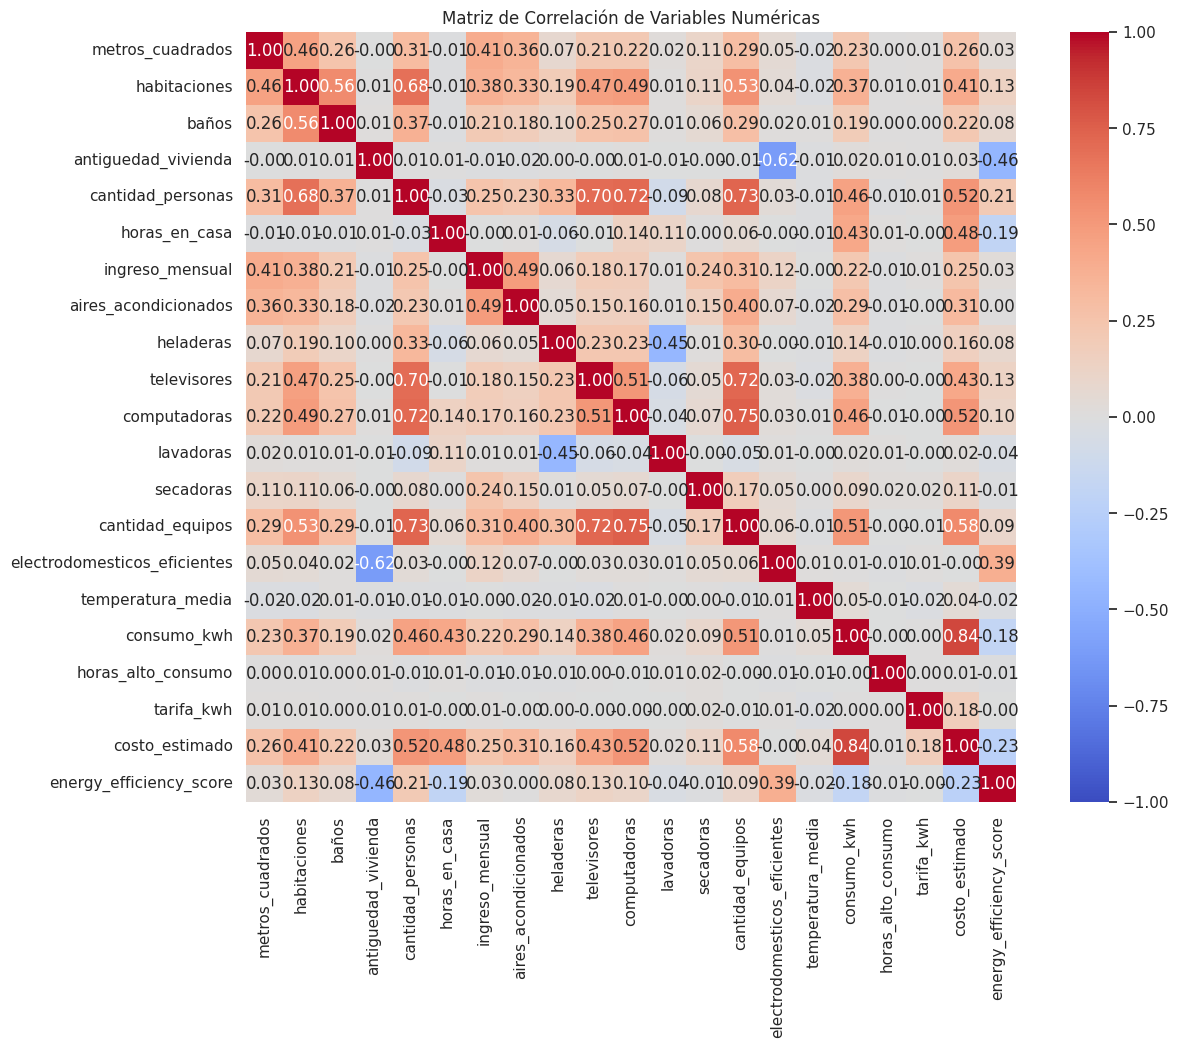

In [7]:
# 4.1 Matriz de Correlación (Solo variables numéricas)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Excluimos 'id' porque no tiene valor predictivo
num_cols = num_cols.drop('id')

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

###  Conclusiones del Análisis de Correlación:

1. **Principales Impulsores del Consumo:** La demanda energética (`consumo_kwh`) está fuertemente determinada por la infraestructura tecnológica interna (`cantidad_equipos` con r = 0.51) y la densidad de habitabilidad (`cantidad_personas` con r = 0.46, y `horas_en_casa` con r = 0.43).
2. **Impacto Financiero Directo:** Existe una correlación lineal crítica y casi perfecta entre el consumo y el `costo_estimado` (r = 0.84), demostrando el impacto económico inmediato del comportamiento energético en la facturación.
3. **El Factor de Obsolescencia:** Se detecta una fuerte relación inversa entre la `antiguedad_vivienda` y la presencia de `electrodomesticos_eficientes` (r = -0.62). Esto evidencia que las propiedades más antiguas sufren un rezago tecnológico estructural que afecta su puntaje de eficiencia general.

# 6. Ingeniería de Variables (Feature Engineering)

En esta sección, generaremos nuevas características a partir de las existentes para enriquecer nuestro conjunto de datos y potencialmente mejorar el rendimiento de los modelos predictivos. También transformaremos las variables categóricas en un formato numérico adecuado para los algoritmos de Machine Learning.

### 6.1 Creación de Nuevas Características

Basado en los gráficos y resultados estadísticos que generamos en la sección 3 del notebook (Análisis Univariado), aquí tienes el análisis que justifica los 1200 kWh como el umbral de 'Consumo Alto':

Distribución de la Cola Larga (Skewness): El histograma mostró que la gran mayoría de los datos se concentran por debajo de los 1,000 kWh. A partir de los 1,200 kWh, la frecuencia de los datos cae drásticamente, lo que indica que cualquier valor por encima de este punto ya no forma parte del comportamiento 'típico' o central de la población.

Método del Boxplot (Rango Intercuartílico): En el diagrama de caja, el 'bigote' superior (que representa el límite de los datos normales o $Q3 + 1.5 \times IQR$$Q3 + 1.5 \times IQR$) termina cerca de los 1,200 kWh. Los puntos aislados que ves a la derecha de ese límite son, por definición estadística, outliers.

Identificación de Anomalías: Al fijar el umbral en 1,200 kWh, estamos separando el consumo residencial/comercial estándar de los casos excepcionales. Estos casos (que llegan hasta los 8,000 kWh) pueden deberse a:

Fugas eléctricas o mal funcionamiento de equipos.
Propiedades con uso industrial no declarado.
Falta extrema de aislamiento térmico combinada con uso intensivo de calefacción/refrigeración.

In [10]:
# Consumo por persona: una métrica para entender la eficiencia individual
df['consumo_por_persona'] = df['consumo_kwh'] / df['cantidad_personas']

# Bandera de Consumo Alto: Basado en el análisis univariado, donde se identificaron outliers extremos por encima de 1200 kWh
df['consumo_alto'] = (df['consumo_kwh'] > 1200).astype(int)

# Mostramos las nuevas características
print(df[['consumo_kwh', 'cantidad_personas', 'consumo_por_persona', 'consumo_alto']].head(100))

    consumo_kwh  cantidad_personas  consumo_por_persona  consumo_alto
0        173.68                  2            86.840000             0
1        583.18                  3           194.393333             0
2        494.45                  7            70.635714             0
3        109.56                  1           109.560000             0
4        380.47                  1           380.470000             0
..          ...                ...                  ...           ...
95       575.82                  1           575.820000             0
96       504.06                  8            63.007500             0
97       352.06                  5            70.412000             0
98       428.31                  2           214.155000             0
99       256.28                  2           128.140000             0

[100 rows x 4 columns]


### 6.2 Codificación de Variables Categóricas (One-Hot Encoding)

Transformaremos las variables categóricas nominales en un formato numérico utilizando One-Hot Encoding. Esto es esencial para que los algoritmos de Machine Learning puedan procesarlas.

In [12]:
# Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Excluir la variable objetivo 'categoria' si es que aún no se ha excluido
if 'categoria' in categorical_cols:
    categorical_cols.remove('categoria')

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Mostrar las primeras filas del DataFrame con las variables codificadas
print("Dimensiones del dataset después de encoding:", df_encoded.shape)
display(df_encoded.head())

Dimensiones del dataset después de encoding: (10000, 45)


,id,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,cantidad_personas,horas_en_casa,ingreso_mensual,aires_acondicionados,heladeras,...,trabajo_remoto_True,calefaccion_True,tipo_calefaccion_Gas,tipo_calefaccion_Losa Radiante,tipo_calefaccion_Ninguna,tipo_iluminacion_LED,tipo_iluminacion_Mixta,factor_estacional_Otoño,factor_estacional_Primavera,factor_estacional_Verano
0,1,90.1,2,2,29.0,2,8.0,1320.89,0,1,...,False,True,False,False,False,False,True,True,False,False
1,2,88.3,1,1,37.0,3,14.8,1661.13,1,2,...,False,True,True,False,False,False,False,False,False,True
2,3,177.7,6,3,26.0,7,8.0,2725.46,4,2,...,False,True,False,False,False,False,True,False,True,False
3,4,138.6,4,2,5.0,1,17.6,2598.16,2,1,...,True,True,False,False,False,True,False,True,False,False
4,5,57.7,1,1,16.0,1,13.9,1033.34,1,1,...,True,True,False,False,False,True,False,False,False,False


### 6.3 Normalización de Datos

Utilizaremos `MinMaxScaler` para llevar todas las variables numéricas a un rango común entre 0 y 1. Esto evita que variables con rangos grandes (como `ingreso_mensual`) tengan un peso desproporcionado comparado con variables de rango pequeño (como `habitaciones`).

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Seleccionamos las columnas numéricas para normalizar (excluyendo el ID y la variable objetivo si existiera como string)
# En df_encoded, casi todo es numérico o booleano (que se comporta como 0/1)
cols_to_scale = df_encoded.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'id' in cols_to_scale:
    cols_to_scale.remove('id')

scaler = MinMaxScaler()
df_normalized = df_encoded.copy()

# Aplicamos la transformación
df_normalized[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

print("Estadísticas después de la normalización (Min/Max):")
display(df_normalized[cols_to_scale].describe().loc[['min', 'max']])

display(df_normalized.head())

Estadísticas después de la normalización (Min/Max):


,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,cantidad_personas,horas_en_casa,ingreso_mensual,aires_acondicionados,heladeras,televisores,...,cantidad_equipos,electrodomesticos_eficientes,temperatura_media,consumo_kwh,horas_alto_consumo,tarifa_kwh,costo_estimado,energy_efficiency_score,consumo_por_persona,consumo_alto
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


,id,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,cantidad_personas,horas_en_casa,ingreso_mensual,aires_acondicionados,heladeras,...,trabajo_remoto_True,calefaccion_True,tipo_calefaccion_Gas,tipo_calefaccion_Losa Radiante,tipo_calefaccion_Ninguna,tipo_iluminacion_LED,tipo_iluminacion_Mixta,factor_estacional_Otoño,factor_estacional_Primavera,factor_estacional_Verano
0,1,0.052538,0.142857,0.25,0.367089,0.142857,0.00000,0.060047,0.0,0.0,...,False,True,False,False,False,False,True,True,False,False
1,2,0.050964,0.000000,0.00,0.468354,0.285714,0.42500,0.076612,0.2,0.5,...,False,True,True,False,False,False,False,False,False,True
2,3,0.129115,0.714286,0.50,0.329114,0.857143,0.00000,0.128430,0.8,0.5,...,False,True,False,False,False,False,True,False,True,False
3,4,0.094935,0.428571,0.25,0.063291,0.000000,0.60000,0.122232,0.4,0.0,...,True,True,False,False,False,True,False,True,False,False
4,5,0.024215,0.000000,0.00,0.202532,0.000000,0.36875,0.046048,0.2,0.0,...,True,True,False,False,False,True,False,False,False,False



### 7. Balanceo de Clases (Resampling)

En esta sección abordamos el desequilibrio entre las categorías de eficiencia energética. Un dataset desbalanceado puede hacer que el modelo ignore la clase minoritaria (`Inefficient`), la cual suele ser la más crítica de identificar.

### Estrategia Combinada:
*   **SMOTE (Synthetic Minority Over-sampling Technique):** Genera nuevos registros sintéticos para las clases minoritarias basándose en los vecinos más cercanos, en lugar de simplemente duplicar filas.
*   **Undersampling:** Reduce el número de muestras de la clase mayoritaria para alcanzar un equilibrio perfecto.
```

Distribución original: Counter({'Moderate': 4495, 'Efficient': 3003, 'Inefficient': 2502})
Distribución después del balanceo: Counter({'Efficient': 4495, 'Inefficient': 4495, 'Moderate': 4495})


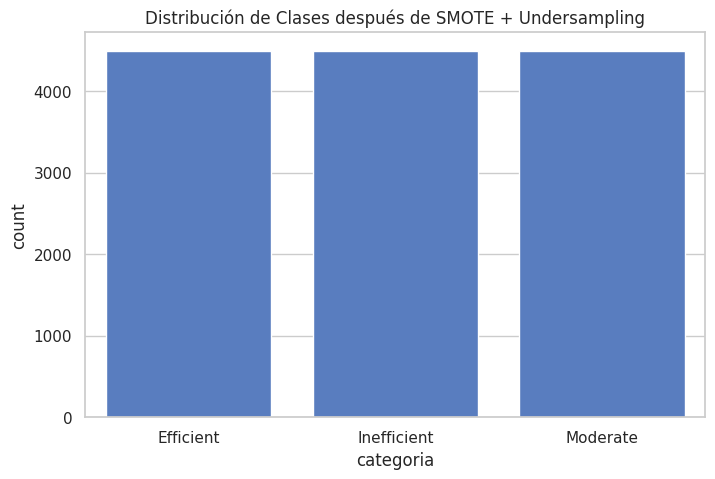

In [18]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

# 1. Separamos variables predictoras (X) y objetivo (y)
# Usamos df_normalized que ya tiene encoding y escalado
X = df_normalized.drop(columns=['id', 'categoria'])
y = df_normalized['categoria']

print(f"Distribución original: {Counter(y)}")

# 2. Definimos la estrategia de balanceo
# Primero sobremuestreamos las minoritarias y luego submuestreamos la mayoritaria
over = SMOTE(sampling_strategy='auto')
under = RandomUnderSampler(sampling_strategy='auto')

steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

# 3. Aplicamos el balanceo
X_resampled, y_resampled = pipeline.fit_resample(X, y)

print(f"Distribución después del balanceo: {Counter(y_resampled)}")

# Visualización del resultado
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled)
plt.title('Distribución de Clases después de SMOTE + Undersampling')
plt.show()


# EXTRA. Análisis de Importancia de Variables (Feature Importance)

Antes de proceder con el ajuste de modelos complejos, evaluamos cuáles son las características que más influyen en la determinación de la eficiencia energética. Utilizaremos un bosque aleatorio (*Random Forest*) para obtener una jerarquía de importancia.
```

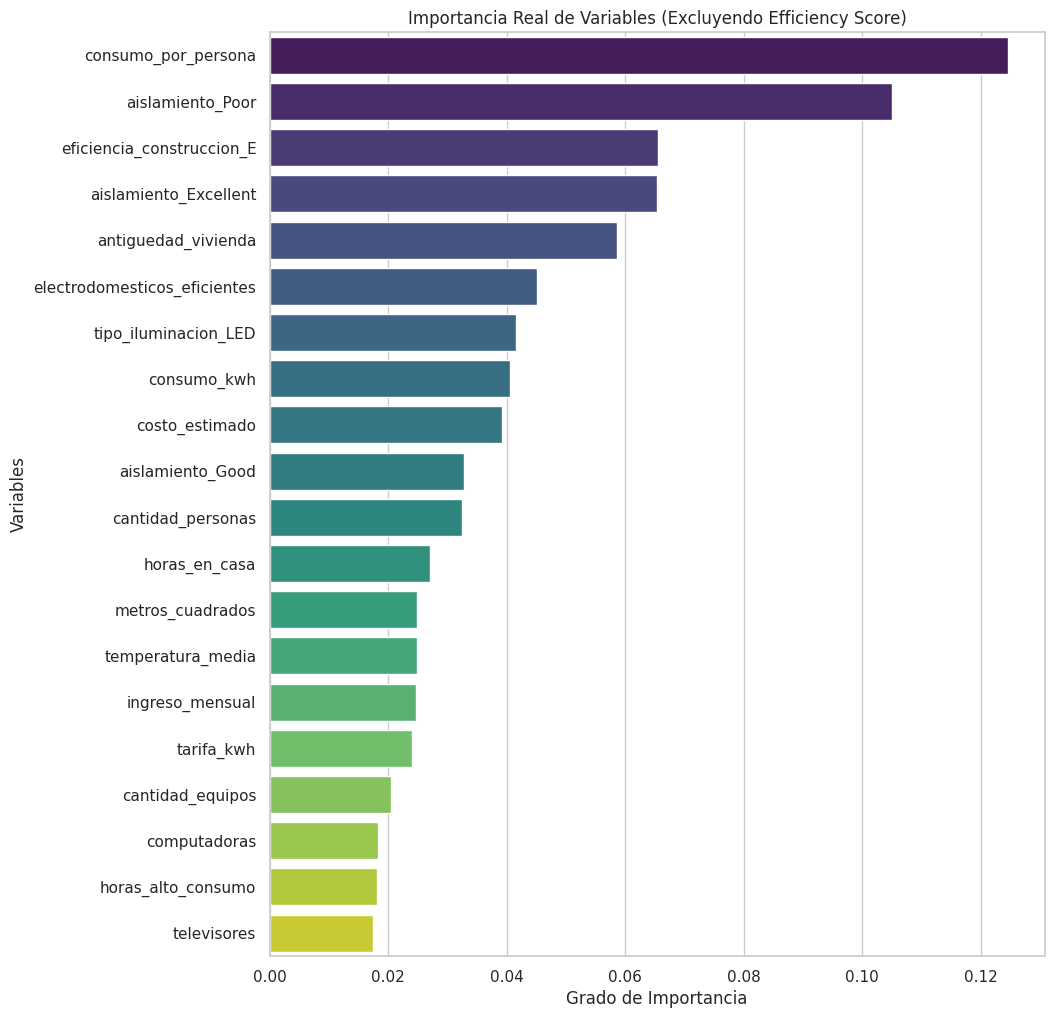

Nuevo Top 5 de variables (factores reales):
                     Variable  Importancia
20        consumo_por_persona     0.124579
26           aislamiento_Poor     0.105051
30  eficiencia_construccion_E     0.065596
24      aislamiento_Excellent     0.065301
3         antiguedad_vivienda     0.058555


In [20]:
from sklearn.ensemble import RandomForestClassifier

# 1. Eliminamos 'energy_efficiency_score' para evitar la redundancia que mencionaste
# Esto obliga al modelo a encontrar patrones en las variables base
X_filtered = X_resampled.drop(columns=['energy_efficiency_score'])

# 2. Inicializar y entrenar el modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_filtered, y_resampled)

# 3. Extraer las importancias
importancias = rf_model.feature_importances_
features = X_filtered.columns

# 4. Crear un DataFrame para visualizar los resultados
feature_importance_df = pd.DataFrame({
    'Variable': features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 5. Visualización
plt.figure(figsize=(10, 12))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df.head(20), hue='Variable', palette='viridis', legend=False)
plt.title('Importancia Real de Variables (Excluyendo Efficiency Score)')
plt.xlabel('Grado de Importancia')
plt.ylabel('Variables')
plt.show()

# Mostrar el nuevo top 5
print("Nuevo Top 5 de variables (factores reales):")
print(feature_importance_df.head(5))